# Notebook 01 — Data Cleaning & Exploratory Data Analysis (EDA)
**CSCI323 Modern Artificial Intelligence — Spring 2026**
**University of Wollongong Dubai (UOWD)**
**Member 1 — Data Lead & GitHub Owner**

---

## What This Notebook Does
This notebook is the first step in the project pipeline. It takes the raw Dubai Land Department
transactions dataset from DubaiPulse and produces a clean, analysis-ready dataset for all other
team members to use.

---

## Steps Performed

**1. Data Loading**
- Loaded raw `Transactions.csv` (1,644,778 rows, 46 columns) from Google Drive

**2. Data Cleaning**
- Dropped all Arabic duplicate columns (_ar suffix)
- Dropped system ID columns (transaction_id, procedure_id, area_id, etc.)
- Dropped building/project name columns (too many nulls, too high cardinality)
- Dropped rent columns (98% null — irrelevant to sales price prediction)
- Removed transactions where actual_worth < 10,000 AED or > 500,000,000 AED (garbage values)
- Dropped rows with null actual_worth or procedure_area (primary target and key feature)
- Filled remaining categorical nulls with 'Unknown' instead of dropping rows
- Fixed invalid/Hijri calendar dates using errors='coerce' and dropped 4 unparseable rows
- Filtered out pre-2000 transactions (data quality issues in early records)

**3. Feature Engineering**
- Extracted year and month from instance_date, then dropped the original date column
- Simplified property_usage_en from 11 classes to 3: Residential, Commercial, Other

**4. Exploratory Data Analysis (7 Visualisations)**
- Plot 1: Property price distribution (raw + log scale)
- Plot 2: Top 20 communities by average property price
- Plot 3: Transaction count by property type and usage
- Plot 4: Price distribution by property type (box plot)
- Plot 5: Correlation matrix of numerical features
- Plot 6: Number of transactions per year (2000–2026)
- Plot 7: Average price by transaction type and registration type

---

## Output
- **cleaned_data.csv** — saved to Google Drive, shared with all team members
- Final shape: **1,637,984 rows × 16 columns**
- Zero null values across all columns

---

## Handoff
`cleaned_data.csv` is ready for Member 2 to begin preprocessing and baseline model training.
All other members (3, 4, 5) should also download this file from Google Drive as the
starting point for their notebooks.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Mounted at /content/drive
Libraries loaded successfully


In [2]:
df = pd.read_csv('/content/drive/MyDrive/CSCI323 - project dld transaction Data/Transactions.csv',
                 on_bad_lines='skip',
                 engine='python')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (1644778, 46)

Columns: ['transaction_id', 'procedure_id', 'trans_group_id', 'trans_group_ar', 'trans_group_en', 'procedure_name_ar', 'procedure_name_en', 'instance_date', 'property_type_id', 'property_type_ar', 'property_type_en', 'property_sub_type_id', 'property_sub_type_ar', 'property_sub_type_en', 'property_usage_ar', 'property_usage_en', 'reg_type_id', 'reg_type_ar', 'reg_type_en', 'area_id', 'area_name_ar', 'area_name_en', 'building_name_ar', 'building_name_en', 'project_number', 'project_name_ar', 'project_name_en', 'master_project_en', 'master_project_ar', 'nearest_landmark_ar', 'nearest_landmark_en', 'nearest_metro_ar', 'nearest_metro_en', 'nearest_mall_ar', 'nearest_mall_en', 'rooms_ar', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price', 'rent_value', 'meter_rent_price', 'no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']


In [3]:
# Drop all Arabic columns
arabic_cols = [col for col in df.columns if col.endswith('_ar')]

# Drop ID columns - no predictive value
id_cols = ['transaction_id', 'procedure_id', 'trans_group_id',
           'property_type_id', 'property_sub_type_id', 'reg_type_id', 'area_id']

# Drop building/project columns - too many nulls and too high cardinality
building_cols = ['building_name_en', 'project_number', 'project_name_en',
                 'master_project_en']

# Drop rent columns - 98% null, irrelevant to sales price prediction
rent_cols = ['rent_value', 'meter_rent_price']

# Drop party count columns - not relevant to price
party_cols = ['no_of_parties_role_1', 'no_of_parties_role_2', 'no_of_parties_role_3']

# Drop procedure_name_en - it's essentially the same info as trans_group_en
other_cols = ['procedure_name_en']

cols_to_drop = arabic_cols + id_cols + building_cols + rent_cols + party_cols + other_cols

df.drop(columns=cols_to_drop, inplace=True)

print("Shape after dropping columns:", df.shape)
print("Remaining columns:", df.columns.tolist())

Shape after dropping columns: (1644778, 15)
Remaining columns: ['trans_group_en', 'instance_date', 'property_type_en', 'property_sub_type_en', 'property_usage_en', 'reg_type_en', 'area_name_en', 'nearest_landmark_en', 'nearest_metro_en', 'nearest_mall_en', 'rooms_en', 'has_parking', 'procedure_area', 'actual_worth', 'meter_sale_price']


In [4]:
# Check before filtering
print("Before filtering actual_worth:")
print(df['actual_worth'].describe())

# Remove transactions where price is unrealistically low or high
# Min 10,000 AED (no property costs less), Max 500,000,000 AED (500M cap)
df = df[(df['actual_worth'] >= 10000) & (df['actual_worth'] <= 500000000)]

print("\nAfter filtering actual_worth:")
print(df['actual_worth'].describe())
print("\nRows remaining:", df.shape[0])

Before filtering actual_worth:
count    1.644778e+06
mean     3.880449e+06
std      6.123458e+07
min      1.000000e+00
25%      7.500000e+05
50%      1.350000e+06
75%      2.500000e+06
max      1.378694e+10
Name: actual_worth, dtype: float64

After filtering actual_worth:
count    1.643744e+06
mean     3.177610e+06
std      1.228245e+07
min      1.000000e+04
25%      7.500000e+05
50%      1.350000e+06
75%      2.500000e+06
max      5.000000e+08
Name: actual_worth, dtype: float64

Rows remaining: 1643744


In [5]:
# Drop rows where actual_worth or procedure_area are null (our main target and key feature)
df.dropna(subset=['actual_worth', 'procedure_area'], inplace=True)

# Fill categorical nulls with 'Unknown' instead of dropping rows
cat_cols_with_nulls = ['property_sub_type_en', 'nearest_landmark_en',
                       'nearest_metro_en', 'nearest_mall_en', 'rooms_en']

for col in cat_cols_with_nulls:
    df[col].fillna('Unknown', inplace=True)

print("Null counts after cleaning:")
print(df.isnull().sum())
print("\nShape:", df.shape)

/tmp/ipykernel_1170/43799266.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


Null counts after cleaning:
trans_group_en          0
instance_date           0
property_type_en        0
property_sub_type_en    0
property_usage_en       0
reg_type_en             0
area_name_en            0
nearest_landmark_en     0
nearest_metro_en        0
nearest_mall_en         0
rooms_en                0
has_parking             0
procedure_area          0
actual_worth            0
meter_sale_price        0
dtype: int64

Shape: (1643744, 15)


In [7]:
# Simplify property_usage_en to 3 classes
def simplify_usage(val):
    if val == 'Residential':
        return 'Residential'
    elif val == 'Commercial':
        return 'Commercial'
    else:
        return 'Other'

df['property_usage_en'] = df['property_usage_en'].apply(simplify_usage)

# Extract year and month from instance_date
# errors='coerce' turns invalid/Hijri dates into NaT so we can drop them
df['instance_date'] = pd.to_datetime(df['instance_date'], dayfirst=True, errors='coerce')

# Drop rows where date couldn't be parsed
invalid_dates = df['instance_date'].isna().sum()
print(f"Dropping {invalid_dates} rows with invalid dates")
df.dropna(subset=['instance_date'], inplace=True)

df['year'] = df['instance_date'].dt.year
df['month'] = df['instance_date'].dt.month
df.drop(columns=['instance_date'], inplace=True)

print("property_usage_en distribution:")
print(df['property_usage_en'].value_counts())
print("\nYear range:", df['year'].min(), "to", df['year'].max())
print("\nFinal shape:", df.shape)

Dropping 4 rows with invalid dates
property_usage_en distribution:
property_usage_en
Residential    1391741
Commercial      162119
Other            89880
Name: count, dtype: int64

Year range: 1966 to 2026

Final shape: (1643740, 16)


In [8]:
# Keep only transactions from 2000 onwards - anything before is likely data entry error
print("Year distribution before filtering:")
print(df['year'].value_counts().sort_index().head(20))

df = df[df['year'] >= 2000]

print("\nYear range after filtering:", df['year'].min(), "to", df['year'].max())
print("Shape after year filter:", df.shape)

# Final null check
print("\nFinal null counts:")
print(df.isnull().sum())

# Final data types
print("\nData types:")
print(df.dtypes)

Year distribution before filtering:
year
1966     1
1967     1
1975     4
1976     6
1977     6
1978     5
1979     2
1980     5
1981     1
1982     4
1983     6
1984    12
1985     9
1986     9
1987    12
1988    27
1989    32
1990    42
1991    24
1992    48
Name: count, dtype: int64

Year range after filtering: 2000 to 2026
Shape after year filter: (1637984, 16)

Final null counts:
trans_group_en          0
property_type_en        0
property_sub_type_en    0
property_usage_en       0
reg_type_en             0
area_name_en            0
nearest_landmark_en     0
nearest_metro_en        0
nearest_mall_en         0
rooms_en                0
has_parking             0
procedure_area          0
actual_worth            0
meter_sale_price        0
year                    0
month                   0
dtype: int64

Data types:
trans_group_en           object
property_type_en         object
property_sub_type_en     object
property_usage_en        object
reg_type_en              object
area_name_

In [9]:
df.to_csv('/content/drive/MyDrive/CSCI323 - project dld transaction Data/cleaned_data.csv', index=False)
print("cleaned_data.csv saved successfully")
print("Final cleaned dataset shape:", df.shape)

cleaned_data.csv saved successfully
Final cleaned dataset shape: (1637984, 16)


In [10]:
# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Plot style set")

Plot style set


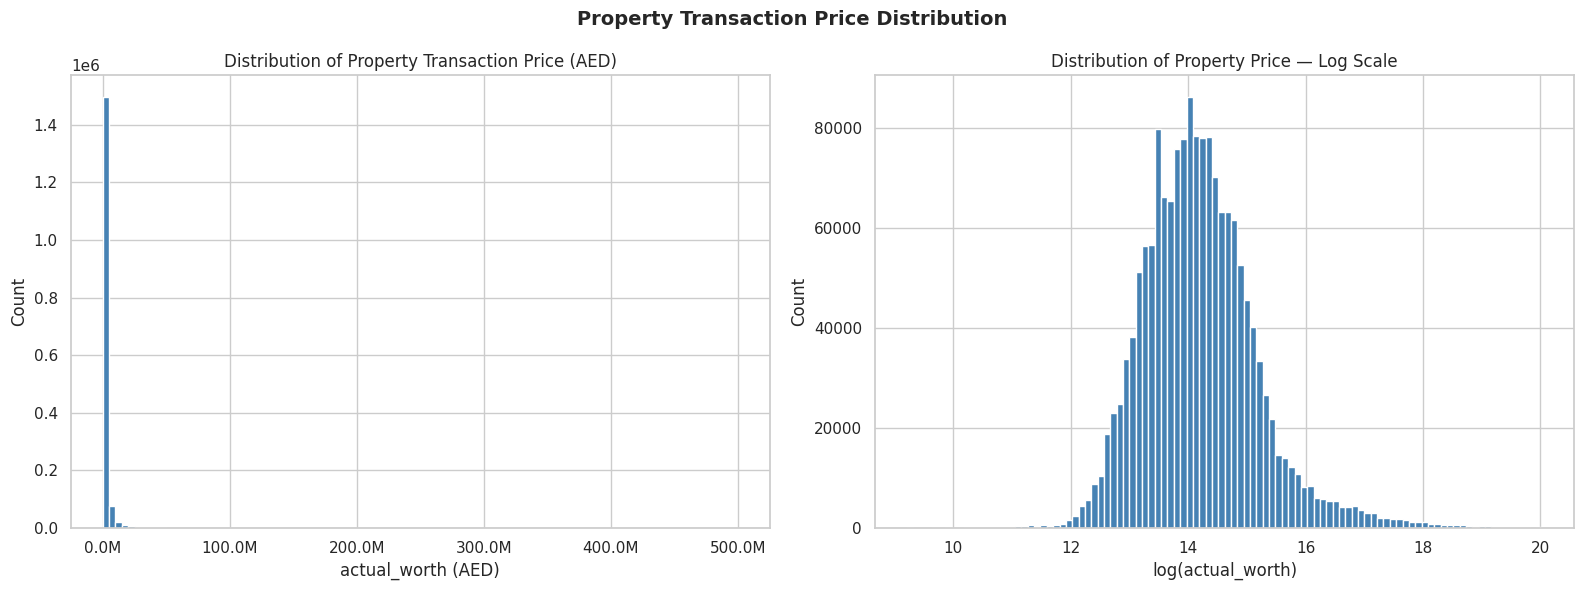

Plot 1 done


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw distribution
axes[0].hist(df['actual_worth'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Property Transaction Price (AED)')
axes[0].set_xlabel('actual_worth (AED)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Right: log scale - better view
axes[1].hist(np.log1p(df['actual_worth']), bins=100, color='steelblue', edgecolor='white')
axes[1].set_title('Distribution of Property Price — Log Scale')
axes[1].set_xlabel('log(actual_worth)')
axes[1].set_ylabel('Count')

plt.suptitle('Property Transaction Price Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 done")

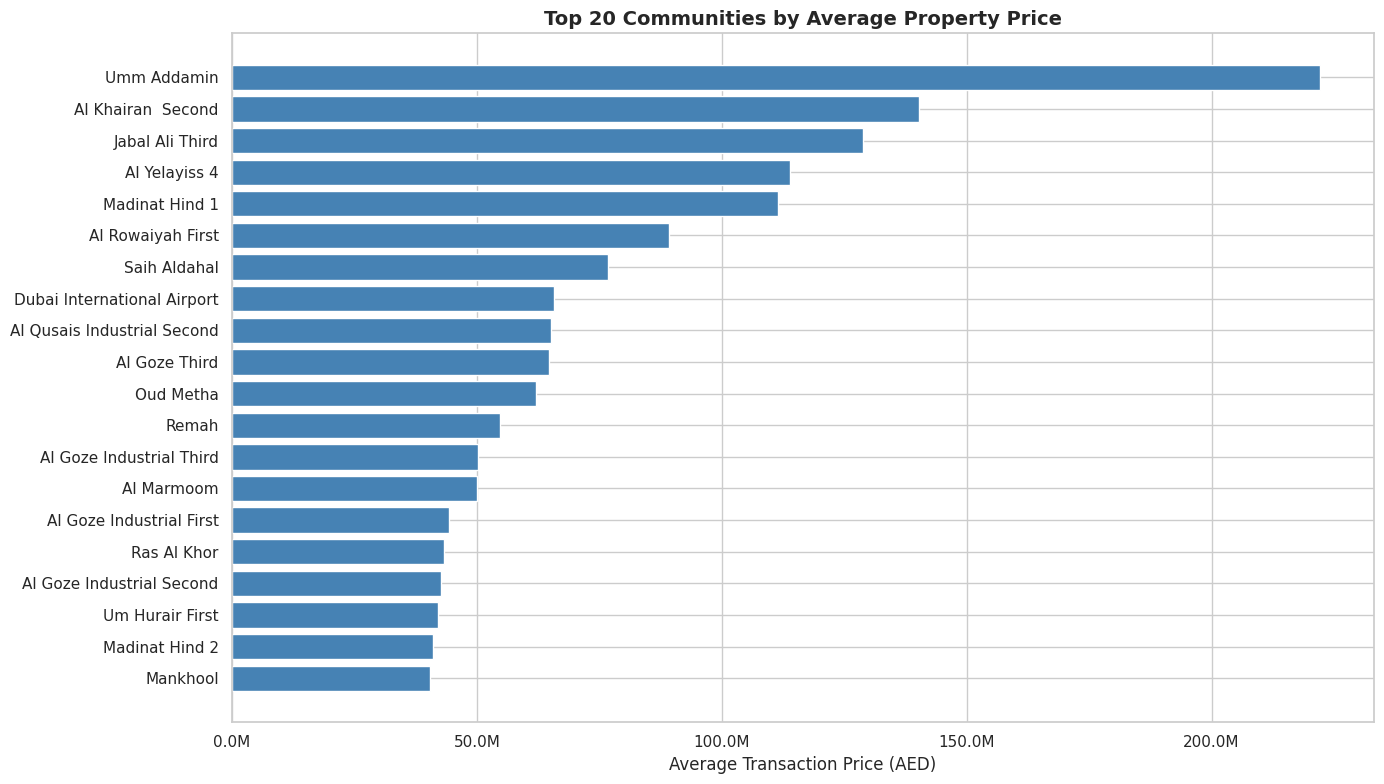

Plot 2 done


In [12]:
top20_areas = (df.groupby('area_name_en')['actual_worth']
               .mean()
               .sort_values(ascending=False)
               .head(20))

plt.figure(figsize=(14, 8))
bars = plt.barh(top20_areas.index[::-1], top20_areas.values[::-1], color='steelblue')
plt.xlabel('Average Transaction Price (AED)')
plt.title('Top 20 Communities by Average Property Price', fontsize=14, fontweight='bold')
plt.xaxis = plt.gca().xaxis
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('avg_price_by_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 done")

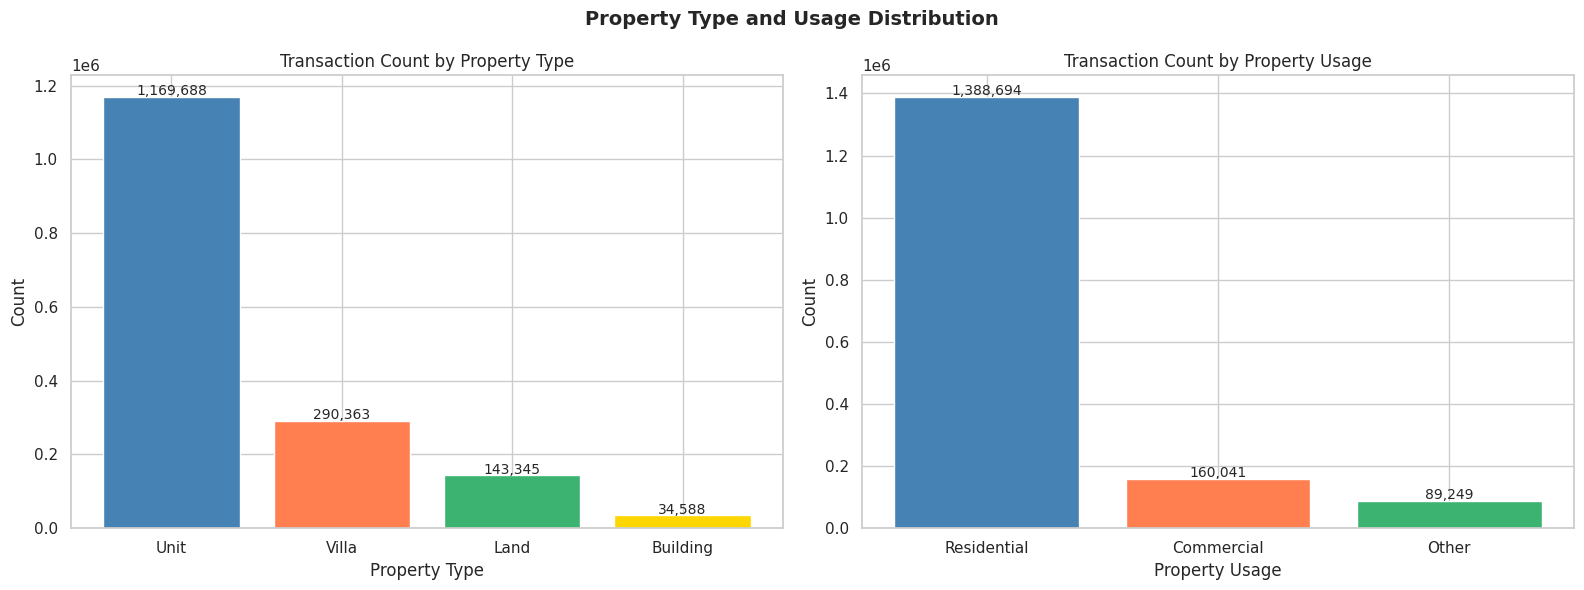

Plot 3 done


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Property type counts
type_counts = df['property_type_en'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color=['steelblue','coral','mediumseagreen','gold'])
axes[0].set_title('Transaction Count by Property Type')
axes[0].set_xlabel('Property Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

# Property usage counts
usage_counts = df['property_usage_en'].value_counts()
axes[1].bar(usage_counts.index, usage_counts.values, color=['steelblue','coral','mediumseagreen'])
axes[1].set_title('Transaction Count by Property Usage')
axes[1].set_xlabel('Property Usage')
axes[1].set_ylabel('Count')
for i, v in enumerate(usage_counts.values):
    axes[1].text(i, v + 5000, f'{v:,}', ha='center', fontsize=10)

plt.suptitle('Property Type and Usage Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('property_type_usage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 done")

/tmp/ipykernel_1170/439559556.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='property_type_en', y='actual_worth',


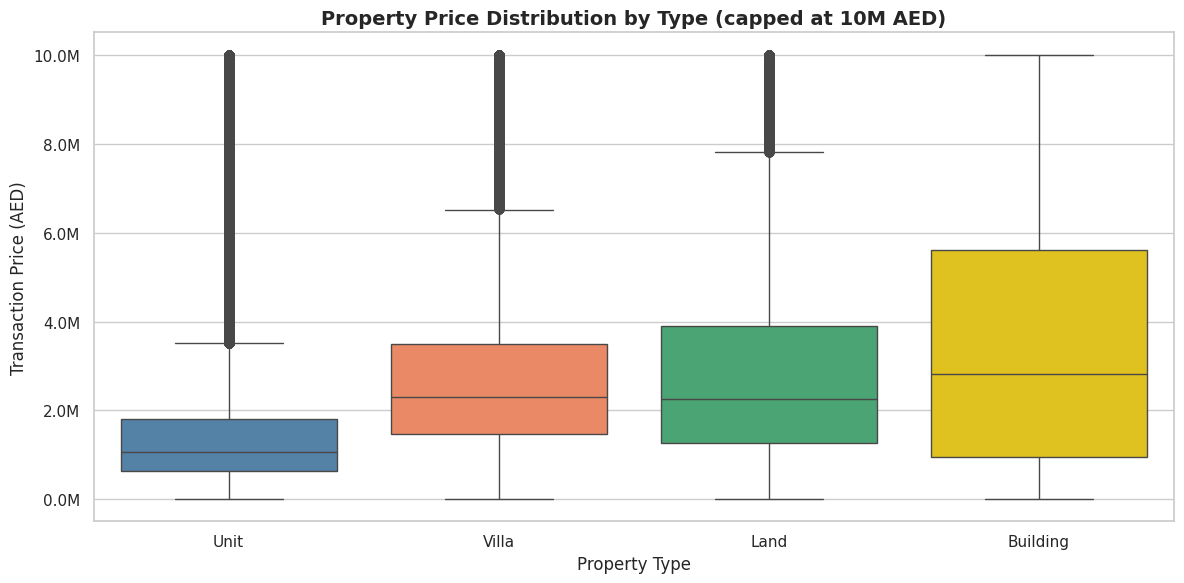

Plot 4 done


In [14]:
plt.figure(figsize=(12, 6))
df_plot = df[df['actual_worth'] <= 10000000]  # cap at 10M for visibility

sns.boxplot(data=df_plot, x='property_type_en', y='actual_worth',
            palette=['steelblue','coral','mediumseagreen','gold'],
            order=['Unit', 'Villa', 'Land', 'Building'])

plt.title('Property Price Distribution by Type (capped at 10M AED)',
          fontsize=14, fontweight='bold')
plt.xlabel('Property Type')
plt.ylabel('Transaction Price (AED)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('price_by_type.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 done")

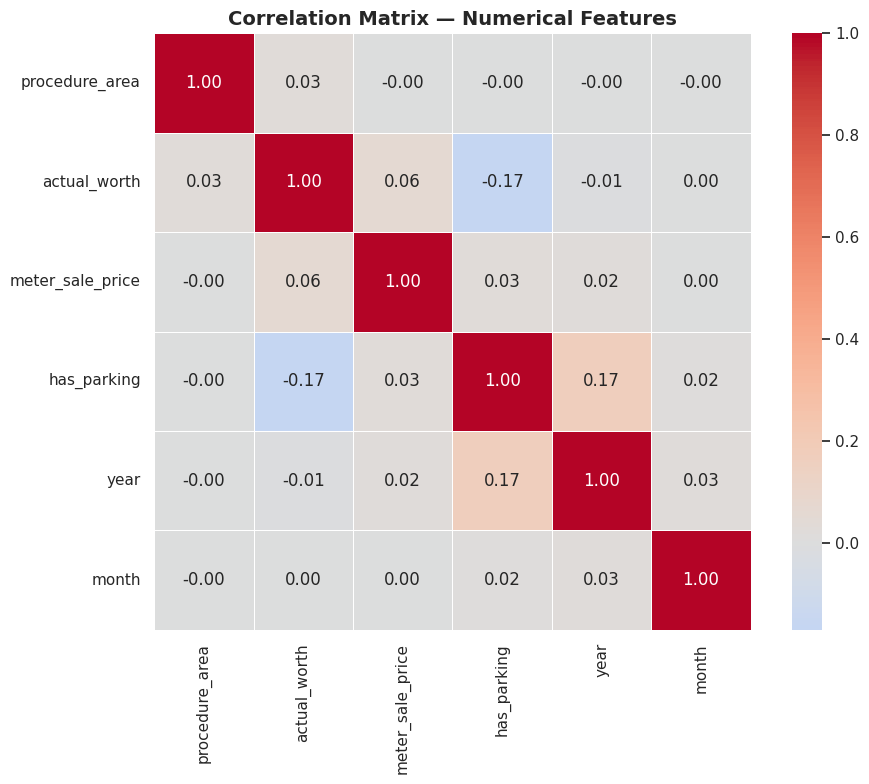

Plot 5 done


In [15]:
plt.figure(figsize=(10, 8))
num_cols = ['procedure_area', 'actual_worth', 'meter_sale_price',
            'has_parking', 'year', 'month']

corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 12})

plt.title('Correlation Matrix — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 done")

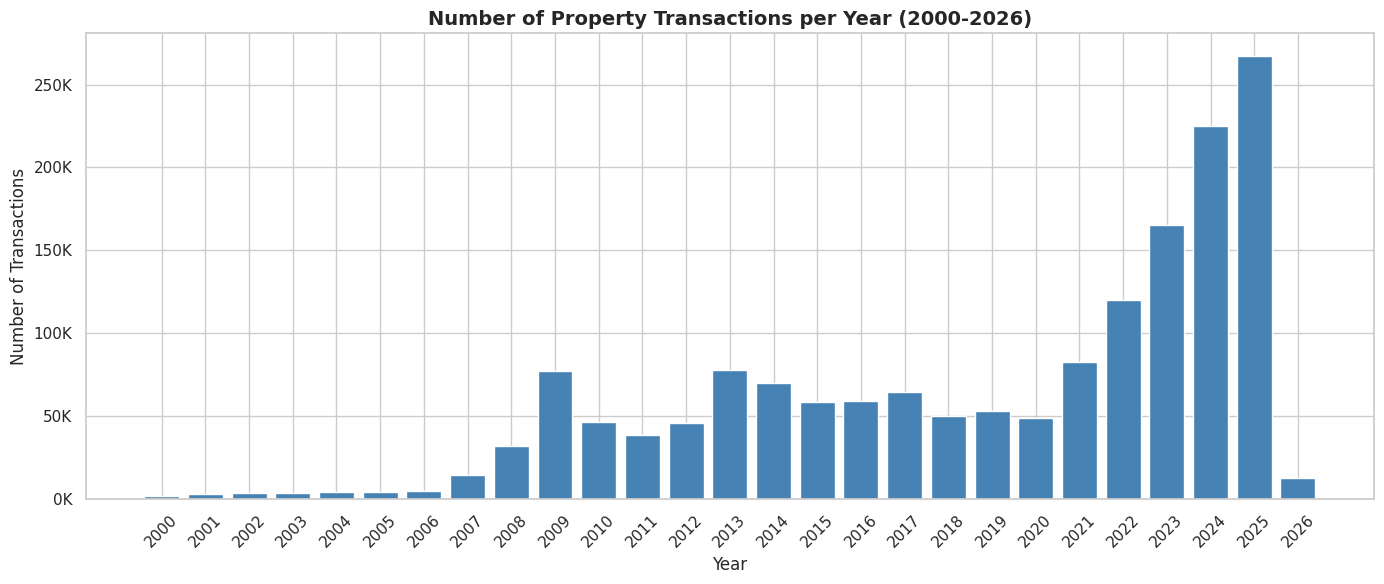

Plot 6 done


In [16]:
yearly = df.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(14, 6))
plt.bar(yearly['year'], yearly['count'], color='steelblue', edgecolor='white')
plt.title('Number of Property Transactions per Year (2000-2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Transactions')
plt.xticks(yearly['year'], rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('transactions_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 done")

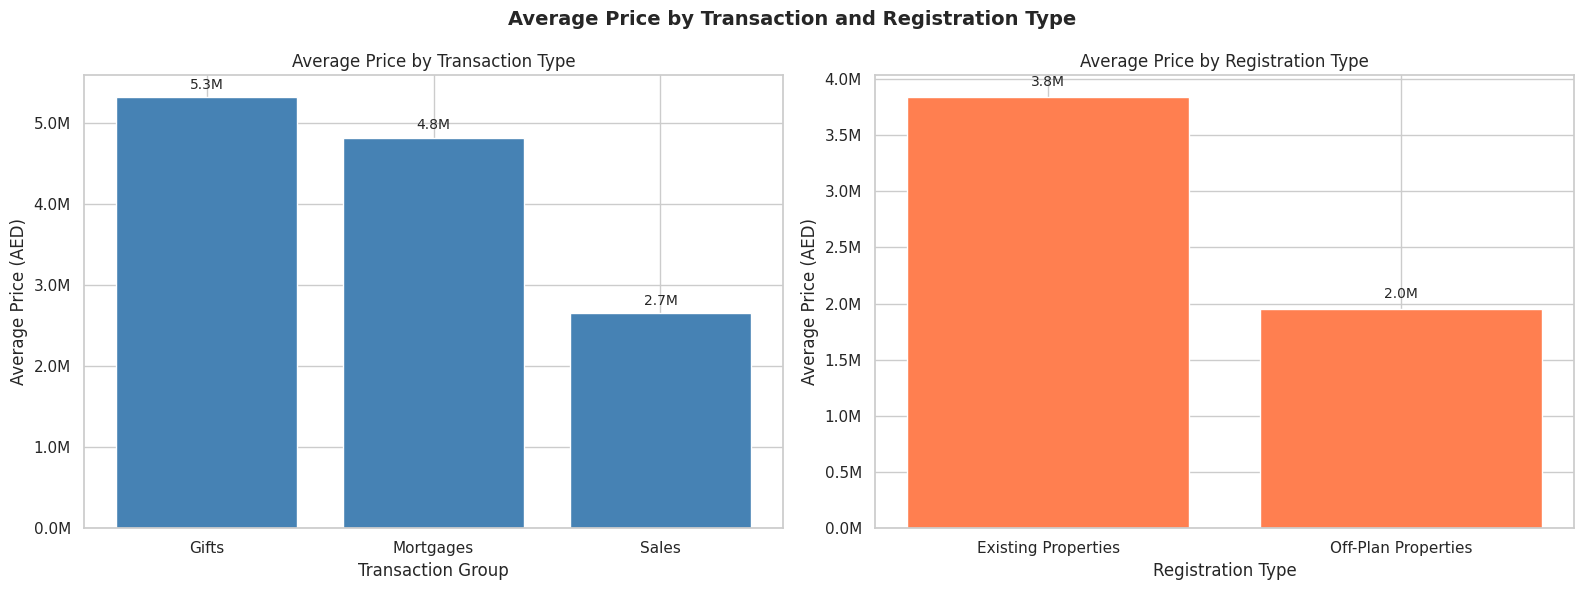

Plot 7 done


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average price by trans_group
trans_avg = df.groupby('trans_group_en')['actual_worth'].mean().sort_values(ascending=False)
axes[0].bar(trans_avg.index, trans_avg.values, color='steelblue')
axes[0].set_title('Average Price by Transaction Type')
axes[0].set_xlabel('Transaction Group')
axes[0].set_ylabel('Average Price (AED)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(trans_avg.values):
    axes[0].text(i, v + 100000, f'{v/1e6:.1f}M', ha='center', fontsize=10)

# Average price by reg_type
reg_avg = df.groupby('reg_type_en')['actual_worth'].mean().sort_values(ascending=False)
axes[1].bar(reg_avg.index, reg_avg.values, color='coral')
axes[1].set_title('Average Price by Registration Type')
axes[1].set_xlabel('Registration Type')
axes[1].set_ylabel('Average Price (AED)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
for i, v in enumerate(reg_avg.values):
    axes[1].text(i, v + 100000, f'{v/1e6:.1f}M', ha='center', fontsize=10)

plt.suptitle('Average Price by Transaction and Registration Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('price_by_trans_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 done")

In [18]:
print("=" * 50)
print("DATASET SUMMARY — AFTER CLEANING")
print("=" * 50)
print(f"Total transactions: {df.shape[0]:,}")
print(f"Total features: {df.shape[1]}")
print(f"Date range: {df['year'].min()} to {df['year'].max()}")
print(f"\nProperty Types:")
for k, v in df['property_type_en'].value_counts().items():
    print(f"  {k}: {v:,} ({v/len(df)*100:.1f}%)")
print(f"\nProperty Usage:")
for k, v in df['property_usage_en'].value_counts().items():
    print(f"  {k}: {v:,} ({v/len(df)*100:.1f}%)")
print(f"\nActual Worth (AED):")
print(f"  Min:    {df['actual_worth'].min():,.0f}")
print(f"  Median: {df['actual_worth'].median():,.0f}")
print(f"  Mean:   {df['actual_worth'].mean():,.0f}")
print(f"  Max:    {df['actual_worth'].max():,.0f}")
print(f"\nTop 5 Communities by transaction count:")
print(df['area_name_en'].value_counts().head())
print(f"\ncleaned_data.csv already saved to Google Drive")
print("=" * 50)
print("EDA COMPLETE — Member 2 can now begin")
print("=" * 50)

DATASET SUMMARY — AFTER CLEANING
Total transactions: 1,637,984
Total features: 16
Date range: 2000 to 2026

Property Types:
  Unit: 1,169,688 (71.4%)
  Villa: 290,363 (17.7%)
  Land: 143,345 (8.8%)
  Building: 34,588 (2.1%)

Property Usage:
  Residential: 1,388,694 (84.8%)
  Commercial: 160,041 (9.8%)
  Other: 89,249 (5.4%)

Actual Worth (AED):
  Min:    10,000
  Median: 1,350,000
  Mean:   3,175,773
  Max:    500,000,000

Top 5 Communities by transaction count:
area_name_en
Marsa Dubai               134725
Al Barsha South Fourth    104987
Al Thanyah Fifth           96407
Burj Khalifa               93461
Business Bay               89706
Name: count, dtype: int64

cleaned_data.csv already saved to Google Drive
EDA COMPLETE — Member 2 can now begin
